В цьому домашньому завданні кожне завдання оцінюється по 10 балів.

 **Завдання 1.** Після перегляду лекцій про поняття функії, вступ до лінійної алгебри і мат. формулювання лін. регресії знайдіть найкращу лінію для прогнозу `charges` за `age` **для некурців** (датафрейм `non_smoker_df`) з допомогою

1. Методу МНК (з використанням тільки `numpy`, без `scikit learn`)

2. Full-Batch градієнтного спуску з `numpy` . Протестуйте 3 різних learning rate і зробіть висновок, який є найкращим виходячи з практик для цього, наведених в лекції. Зверніть увагу, що на вхід треба набір даних дворозміний, для цього можливо треба буде трансформувати Ваші дані X в формат, як був в лекції "Математичне формулювання лінійної регресії". Також, градієнтний спуск в нашому випадку може розходитись з навчальним рейтом 0.1, бо цей рейт в цій задачі завеликий. Спробуйте нижчі рейти.
3. З `scikit-learn.LinearRegression`. Тут зверніть увагу, що вхід `X` має бути двовимірним масивом, тому нам потрібно передати dataframe, а не окрему колонку. Якщо у Вас X - колонка (а у Вас так мало б бути), то можна скористатись `X.to_frame()` щоб конвертувати колонку в датафрейм.

Для кожного методу
- знайдіть і виведіть коефіцієнти моделі
- обчисліть прогнози моделі і збережіть в окрему змінну
- порахуйте точність прогнозу RMSE  

Для градієнтного спуску виведіть графік помилки в залежності від ітерації.

А також побудуйте на одному графіку дані `age` проти `charges` в вигляді діаграми розсіювання і всі три лінії регресії, знайдені кожним з методів (для град. спуску оберіть варіант з тим learning rate, який виявився найкращим).

Зробіть висновки, чи відрізняються результати моделей?
Чи є знайдены параметри моделы близькими до ваших найкращих припущень?

In [61]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [62]:
!ls drive/MyDrive/'Colab Notebooks'/medical-charges.csv

'drive/MyDrive/Colab Notebooks/medical-charges.csv'


In [63]:
line = 'drive/MyDrive/Colab Notebooks/medical-charges.csv'

In [64]:
import pandas as pd
medical_df = pd.read_csv(line)
non_smoker_df = medical_df[medical_df.smoker == 'no'].sort_values(by='age')
non_smoker_df.head()

,age,sex,bmi,children,smoker,region,charges
1,18,male,33.77,1,no,southeast,1725.5523
1317,18,male,53.13,0,no,southeast,1163.4627
1334,18,female,31.92,0,no,northeast,2205.9808
22,18,male,34.10,0,no,southeast,1137.0110
571,18,female,37.29,1,no,southeast,2219.4451


### Методу МНК (з використанням тільки numpy, без scikit learn)

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [66]:
X = non_smoker_df['age']
y = non_smoker_df['charges']

X_with_intercept = np.c_[np.ones(X.shape[0]), X]
X_with_intercept

array([[ 1., 18.],
       [ 1., 18.],
       [ 1., 18.],
       ...,
       [ 1., 64.],
       [ 1., 64.],
       [ 1., 64.]])

In [67]:
def normal_equations(X,y):
    """Computes the closed-form solution to linear regression"""
    theta = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
    return theta

In [68]:
MNK_coefs = normal_equations(X_with_intercept, y)
MNK_coefs

array([-2091.42055657,   267.24891283])

In [69]:
predictions_MNK = np.dot(X_with_intercept, MNK_coefs)
predictions_MNK

array([ 2719.0598744 ,  2719.0598744 ,  2719.0598744 , ...,
       15012.50986463, 15012.50986463, 15012.50986463])

In [70]:
rmse_MNK = np.sqrt(mean_squared_error(y, predictions_MNK))
print(rmse_MNK)

4662.505766636395


### Full-Batch градієнтного спуску з numpy . Протестуйте 3 різних learning rate і зробіть висновок, який є найкращим виходячи з практик для цього, наведених в лекції. Зверніть увагу, що на вхід треба набір даних дворозміний, для цього можливо треба буде трансформувати Ваші дані X в формат, як був в лекції "Математичне формулювання лінійної регресії". Також, градієнтний спуск в нашому випадку може розходитись з навчальним рейтом 0.1, бо цей рейт в цій задачі завеликий. Спробуйте нижчі рейти.

In [71]:
X = non_smoker_df['age'].to_numpy().reshape(-1, 1)
y = non_smoker_df['charges'].to_numpy()

In [72]:
def full_batch_gradient_descent(X, y, lr, epochs):
    m, b = 0.0, 0.0  # Початкові параметри
    n = len(y)
    errors = []
    for _ in range(epochs):
        y_pred = m * X[:, 0] + b
        error = y_pred - y
        errors.append(sum(error**2))
        m_gradient = (2/n) * np.dot(error, X[:, 0])
        b_gradient = (2/n) * np.sum(error)
        m = m - lr * m_gradient
        b = b - lr * b_gradient
    return m, b, errors

In [73]:
m, b, errors_1 = full_batch_gradient_descent(X, y, lr=0.001, epochs=10000)
predictions_fbgd_1 = m * X[:, 0] + b
# rmse_fbgd_1 = np.sqrt(mean_squared_error(y, predictions_fbgd))
# print(rmse_fbgd_1)

m, b

/tmp/ipython-input-4162110832.py:8: RuntimeWarning: overflow encountered in scalar add
  errors.append(sum(error**2))
/tmp/ipython-input-4162110832.py:8: RuntimeWarning: overflow encountered in square
  errors.append(sum(error**2))
/tmp/ipython-input-4162110832.py:11: RuntimeWarning: invalid value encountered in scalar subtract
  m = m - lr * m_gradient


(np.float64(nan), np.float64(nan))

In [74]:
m, b, errors_2 = full_batch_gradient_descent(X, y, lr=0.0001, epochs=10000)
predictions_fbgd_2 = m * X[:, 0] + b
rmse_fbgd_2 = np.sqrt(mean_squared_error(y, predictions_fbgd))
print(rmse_fbgd_2)

m, b

4715.3497503703065


(np.float64(229.6120874611436), np.float64(-419.8307604133534))

In [75]:
m, b, errors_3 = full_batch_gradient_descent(X, y, lr=0.000001, epochs=10000)
predictions_fbgd_3 = m * X[:, 0] + b
rmse_fbgd_3 = np.sqrt(mean_squared_error(y, predictions_fbgd))
print(rmse_fbgd_3)

m, b

4715.3497503703065


(np.float64(220.15455540263423), np.float64(0.2130113538547516))

In [76]:
predictions_fbgd_3

array([ 3962.9950086 ,  3962.9950086 ,  3962.9950086 , ...,
       14090.10455712, 14090.10455712, 14090.10455712])

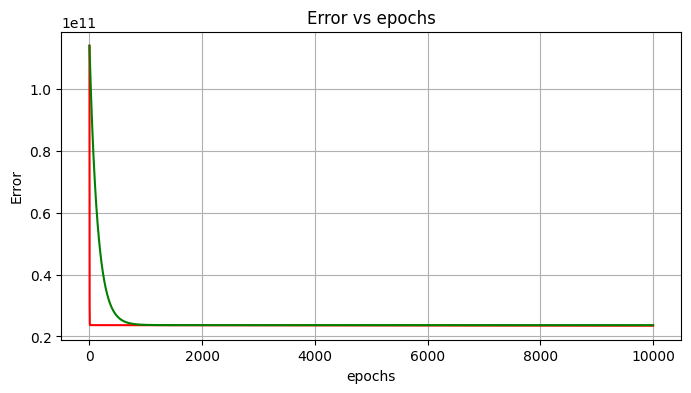

In [77]:
### error visualisation

plt.figure(figsize=(8, 4))
#plt.plot(range(10000), errors_1, color = 'blue')
plt.plot(range(10000), errors_2, color = 'red')
plt.plot(range(10000), errors_3, color = 'green')
plt.xlabel("epochs")
plt.ylabel("Error")
plt.title("Error vs epochs")
plt.grid(True)
plt.show()


**Висновки**

Я спробувала 3 різних навчальних рейта: 0.001, 0.0001, 0.00001. В першій спробі градієнтий спуск не зійшовся, у випадках 2 і 3 зійшовся, але при lr = 0.0001 помилка = 4696.33, а при lr = 0.000001 помилка = 4715.35, тобто при меньшому навчальному рейті за 10000 epochs алгоритм не дійшов до оптимального значення

### З scikit-learn.LinearRegression. Тут зверніть увагу, що вхід X має бути двовимірним масивом, тому нам потрібно передати dataframe, а не окрему колонку. Якщо у Вас X - колонка (а у Вас так мало б бути), то можна скористатись X.to_frame() щоб конвертувати колонку в датафрейм.

In [78]:
from sklearn.linear_model import LinearRegression

X = non_smoker_df[['age']]

lin_reg = LinearRegression()  # fit_intercept=True за замовчуванням
lin_reg.fit(X, y)
predictions_sklearn = lin_reg.predict(X)

print("intercept:", lin_reg.intercept_)
print("slope:", lin_reg.coef_[0])
predictions_sklearn

intercept: -2091.4205565650864
slope: 267.2489128311996


array([ 2719.0598744 ,  2719.0598744 ,  2719.0598744 , ...,
       15012.50986463, 15012.50986463, 15012.50986463])

In [79]:
rmse_sklearn = np.sqrt(mean_squared_error(y, predictions_sklearn))
print(rmse_sklearn)

4662.505766636395


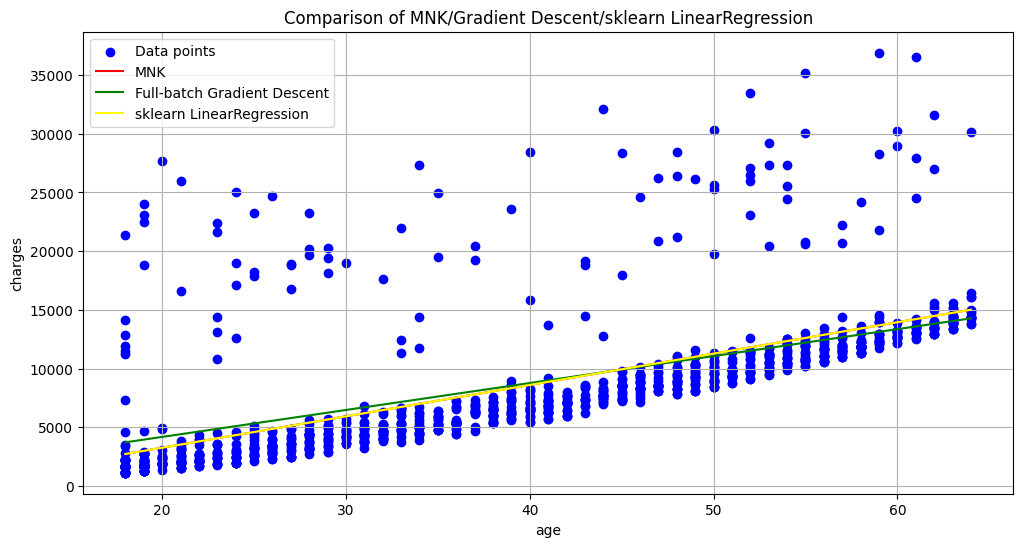

In [80]:
# Візуалізація результатів
plt.figure(figsize=(12, 6))
plt.scatter(non_smoker_df['age'], y, color='blue', label='Data points')
plt.plot(non_smoker_df['age'], predictions_MNK, color='red', label='MNK')
plt.plot(non_smoker_df['age'], predictions_fbgd_2, color='green', label='Full-batch Gradient Descent')
plt.plot(non_smoker_df['age'], predictions_sklearn, color='yellow', label='sklearn LinearRegression')
plt.title('Comparison of MNK/Gradient Descent/sklearn LinearRegression')
plt.xlabel('age')
plt.ylabel('charges')
plt.legend()
plt.grid(True)
plt.show()

In [81]:
print('RMSE_MNK:', rmse_MNK.round(2))
print('RMSE_fbgd:', rmse_fbgd_2.round(2))
print('RMSE_sklearn:', rmse_sklearn.round(2))

RMSE_MNK: 4662.51
RMSE_fbgd: 4715.35
RMSE_sklearn: 4662.51


**Висновки**

Як ми бачимо моделі методом МНК і sklearn linear regression вийшлі однакові (це видно і на візуалізації, лінії зʼєднуються в одну), що логічно, бо використовується однаковий алгоритм. Помилка в моделі Full-Batch градієнтного спуску трохи більше (4696.33 проти 4662.51)

В попередньому домашньому задані мої параметри були w = 260
b = -2500, RMSE = 4714.99, помилка більше, параметри підібрані гірше ніж в прорахованих моделях

 **Завдання 2.** Навчіть модель лінійної регресії з допомогою sklearn оцінювати розмір медичних збори для **курців** за їх віком.
Виведіть
- точність моделі
-  коефіцієнти
-  візуалізуйте модель у вигляді лінії на графіку розсіювання `age` проти `charges`

і зробіть висновки, чи це хороша модель, чи ви б її використовували в компанії?

In [82]:
smoker_df = medical_df[medical_df.smoker == 'yes'].sort_values(by='age')
smoker_df.head()

,age,sex,bmi,children,smoker,region,charges
1204,18,female,27.280,3,yes,southeast,18223.45120
157,18,male,25.175,0,yes,northeast,15518.18025
161,18,female,36.850,0,yes,southeast,36149.48350
1170,18,male,27.360,1,yes,northeast,17178.68240
250,18,male,17.290,2,yes,northeast,12829.45510


In [83]:
X = smoker_df[['age']]
y = smoker_df['charges']

lin_reg = LinearRegression()  # fit_intercept=True за замовчуванням
lin_reg.fit(X, y)
predictions_sklearn = lin_reg.predict(X)

rmse_sklearn = np.sqrt(mean_squared_error(y, predictions_sklearn))
print('RMSE:', rmse_sklearn)
r2 = r2_score(y, predictions_sklearn)
print('R^2:', r2)

print("intercept:", lin_reg.intercept_)
print("slope:", lin_reg.coef_[0])
#predictions_sklearn

RMSE: 10711.00334810241
R^2: 0.1355892409608408
intercept: 20294.128126915974
slope: 305.23760210982886


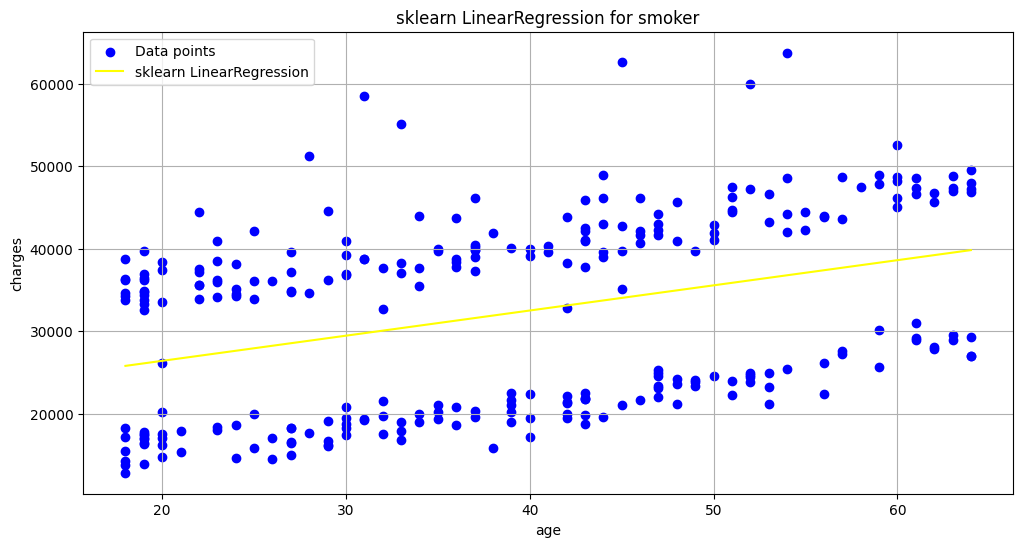

In [84]:
# Візуалізація результатів
plt.figure(figsize=(12, 6))
plt.scatter(smoker_df['age'], y, color='blue', label='Data points')
plt.plot(smoker_df['age'], predictions_sklearn, color='yellow', label='sklearn LinearRegression')
plt.title('sklearn LinearRegression for smoker')
plt.xlabel('age')
plt.ylabel('charges')
plt.legend()
plt.grid(True)
plt.show()

In [85]:
smoker_df['charges'].describe()

,charges
count,274.000000
mean,32050.231832
std,11541.547176
min,12829.455100
25%,20826.244213
50%,34456.348450
75%,41019.207275
max,63770.428010


**Висновки**

Як ми бачимо на графіку, дані складаються із двох різних підгруп і побудована модель не дуже добре описує дані. Ймовірно якійсь інший параметр впливає на charges. Те саме підтверджують цифри: помилка RMSE = 10711, а  стандартне відхилення 11541.55, $ R^2 $ = 0.14. Тобто модель пояснює лише близько 14% варіації витрат, трохи краще ніж, якщо б ми витрати прогнозували середнім значенням. Думаю не варто використовувати таку модель в компанії